# Predictive ablation campaign: training-check scaffold

This notebook is the starting scaffold for `kidney-architecture-predictive`
(`architecture_predictive_experiment.yaml`) — the contractive/contrastive/multi-label
head ablation campaign described in `tmp/runny/runny.md`. It does **not** draw
scientific conclusions yet: it only (1) loads every completed run of the campaign and
(2) checks that training actually completed and produced sane, non-broken artifacts
(loss curves, no NaN/Inf, non-empty weights). Comparative analysis (which ablation
wins, AUPRC per molecule, spatial patterns, ...) is deliberately left for a follow-up
pass on top of this scaffold.

**Grid shape**: one architecture (`conv1d-ae-32-16-8-latent-10`) x 7 paired objective
ablations x 5 repetitions = 35 tasks, one shared `joint_predictive` phase (15 epochs).


In [1]:
import os
from pathlib import Path

import pandas as pd

current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper.visualization import resolve_theme


## Config

`STATUS_DIRECTORY` points at the **entropy** orchestration mirror
(`~/entropy-runs/<experiment>/<run>/plan/status/`), not at
`data/kidney_workspace/configs/execution/...`. Two reasons this campaign cannot be read
with the generic `analysis.autoencoder.experiments.campaign_reader.read_campaign`:

1. **Path layout mismatch.** `read_campaign` looks for
   `<workspace>/configs/execution/<experiment_name>/status/`. Since the CLI's namespace
   change (`naming.campaign_identifier`), the real on-disk directory is
   `<workspace>/configs/execution/<experiment_name>__cfg_<fingerprint>/status/` — the
   promised compatibility symlinks (`migration.py` in the earlier session log) were
   never committed (`git log` has no `migration.py` at any revision) and none exist on
   disk locally, so `read_campaign` cannot find this campaign — or the binning campaign
   — under their plain `experiment_name` any more. This is a real regression in
   `campaign_reader.py`, not something specific to this notebook; flagged here rather
   than silently worked around in the library.
2. **This campaign ran on SLURM (entropy), not the local backend.** Its `status`/
   `checkpoints` therefore live under the entropy run's own `plan/` staging directory,
   not under `data/kidney_workspace/configs/execution/`. The local
   `configs/execution/kidney-architecture-predictive__cfg_b913d4d7e9e4/` directory is a
   stale local *preflight/test* run (different config fingerprint, no `status/`) and is
   not used below.

Each status record's own `result.model_path` is also unusable as-is: it is the SLURM
node's ephemeral scratch path (`/tmp/ms488923/...`), already cleaned up. The artifacts
were separately copied back into the repo's model store — `runtime.model_name` in each
task record gives the exact directory name under `MODEL_STORE_DIRECTORY` instead.


In [2]:
WORKSPACE = Path("data/kidney_workspace")
MODEL_CONTEXT = "kidney"
MODEL_STORE_DIRECTORY = WORKSPACE / "models" / MODEL_CONTEXT

EXPERIMENT_NAME = "kidney-architecture-predictive"
EXPERIMENT_YAML = Path(
    "assets/experiments/08_26/23_08_26_architecture_predictive/architecture_predictive_experiment.yaml"
)

# Entropy orchestration mirror synced locally per tmp/runny/runny.md's rsync recipe.
# Update this if a later run under a different `predictive-<date>-<n>` name is analyzed.
ENTROPY_RUN_DIRECTORY = Path.home() / "entropy-runs" / EXPERIMENT_NAME / "predictive-20260824-04"
STATUS_DIRECTORY = ENTROPY_RUN_DIRECTORY / "plan" / "status"

theme = resolve_theme(None)
theme.apply()


## Load task records

One record per completed task, read directly from the entropy `plan/status/*.yaml`
manifests (`task_*.yaml`, excluding the `*-progress.yaml` snapshots) — the same manifest
shape `campaign_reader._build_task` expects, just read locally instead of through that
module for the reasons above.


In [3]:
import yaml


def load_task_records(status_directory: Path) -> list[dict]:
    """Read every ``task_*.yaml`` manifest into one flat record per task."""
    records = []
    manifest_paths = sorted(
        path for path in status_directory.glob("task_*.yaml") if not path.name.endswith("-progress.yaml")
    )
    for manifest_path in manifest_paths:
        payload = yaml.safe_load(manifest_path.read_text(encoding="utf-8")) or {}
        for task_id, record in payload.get("records", {}).items():
            task_definition = record.get("task", {})
            records.append(
                {
                    "task_id": task_id,
                    "status": record.get("status", "unknown"),
                    "grid_id": task_definition.get("grid_id"),
                    "repetition": task_definition.get("repetition"),
                    "grid_parameters": task_definition.get("grid_parameters", {}),
                    "model_name": task_definition.get("runtime", {}).get("model_name"),
                }
            )
    return records


task_records = load_task_records(STATUS_DIRECTORY)
print(f"read {len(task_records)} task manifest(s) from {STATUS_DIRECTORY}")


read 35 task manifest(s) from /home/max/entropy-runs/kidney-architecture-predictive/predictive-20260824-04/plan/status


## Objective labels

`grid_parameters["objectives"]` has no `name` field (unlike `architectures`) — each
ablation is identified only by which loss components it composes. `describe_objective`
derives a short, stable label from that structure instead of hardcoding
`grid_0000..grid_0006 -> label` by position, so the notebook keeps describing the grid
correctly if the YAML's ablation list is reordered or extended later.


In [4]:
def describe_objective(objectives: dict) -> str:
    """Derive a short label for one ``objectives`` grid value from its loss composition."""
    head_losses = objectives.get("heads", {}).get("molecule_primary", {})
    head_kind = next(iter(head_losses), "unknown_head")

    parts = [head_kind]
    if "contractive" in objectives.get("regularization", {}):
        parts.append("contractive")

    contrastive_params = (
        objectives.get("contrastive", {}).get("peak_permutation", {}).get("params", {})
    )
    peak_method = contrastive_params.get("peak_selection_method")
    if peak_method == "permutation_random":
        parts.append("peak_random")
    elif peak_method == "permutation_label_invariant":
        parts.append("peak_label_invariant")
    elif peak_method is not None:
        parts.append(peak_method)

    negative_weighting = contrastive_params.get("negative_weighting_method")
    if negative_weighting:
        parts.append(f"negw_{negative_weighting}")

    return "+".join(parts)


for record in task_records:
    grid = record["grid_parameters"]
    record["architecture"] = grid.get("architectures", {}).get("name")
    record["objective"] = describe_objective(grid.get("objectives", {}))

tasks_df = pd.DataFrame(task_records)
tasks_df = tasks_df.sort_values(["grid_id", "repetition"]).reset_index(drop=True)

objective_by_grid = tasks_df.drop_duplicates("grid_id")[["grid_id", "objective"]].set_index("grid_id")["objective"]
print("objective ablations:")
for grid_id, objective in objective_by_grid.items():
    print(f"  {grid_id}: {objective}")

print()
print(f"architectures: {sorted(tasks_df['architecture'].unique())}")
print(f"repetitions per grid cell: {sorted(tasks_df['repetition'].unique())}")
print(tasks_df["status"].value_counts())


objective ablations:
  grid_0000: balanced_bce
  grid_0001: balanced_bce+contractive
  grid_0002: balanced_bce+peak_random
  grid_0003: balanced_bce+peak_label_invariant
  grid_0004: balanced_bce+contractive+peak_label_invariant
  grid_0005: balanced_bce+contractive+peak_label_invariant+negw_multilabel_jaccard
  grid_0006: nnpu+contractive+peak_label_invariant

architectures: ['conv1d-ae-32-16-8-latent-10']
repetitions per grid cell: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
status
completed    35
Name: count, dtype: int64


### Stable colors across every plot

`VisualizationTheme.color_for_model(name, index)` falls back to picking a palette color
by **position** in whatever list happens to be passed at call time. Every plot below
only includes the objectives that actually log a given loss component (e.g. only 4 of 7
objectives log `contractive`) — so if each plot independently computed
`sorted(objectives_present)`, the same objective could land at a different palette
index, and therefore a different color, in different figures (exactly what happened
before this cell existed). `VisualizationTheme.model_overrides` is the theme's existing
mechanism for pinning colors past that (`"Optional stable model-name color mapping"`);
it is just built once here, from the **full** objective list, and applied to `theme`
before any plotting happens below — so `color_for_model` now returns the same color for
one objective in every figure, regardless of which subset of objectives that particular
figure happens to include.


In [5]:
from dataclasses import replace

objective_order = sorted(tasks_df["objective"].unique())
objective_colors = {
    objective: theme.color_for_model(objective, index)
    for index, objective in enumerate(objective_order)
}
theme = replace(theme, model_overrides=objective_colors)
theme.apply()
objective_colors


{'balanced_bce': '#0072B2',
 'balanced_bce+contractive': '#D55E00',
 'balanced_bce+contractive+peak_label_invariant': '#009E73',
 'balanced_bce+contractive+peak_label_invariant+negw_multilabel_jaccard': '#CC79A7',
 'balanced_bce+peak_label_invariant': '#E69F00',
 'balanced_bce+peak_random': '#56B4E9',
 'nnpu+contractive+peak_label_invariant': '#7A7A7A'}

## Load model artifacts and check they are actually there

`model_name` (from `runtime.model_name`, not the stale scratch `result.model_path`)
gives the on-disk directory directly. Every `completed` task should have a non-empty
`config.json`, `history.json`, and `weights.pt` under it.


In [6]:
import json


def artifact_paths(model_name: str) -> dict[str, Path]:
    model_directory = MODEL_STORE_DIRECTORY / model_name / "config"
    return {
        "config": model_directory / "config.json",
        "history": model_directory / "history.json",
        "weights": model_directory / "weights.pt",
    }


configs: dict[str, dict] = {}
histories: dict[str, list] = {}
artifact_rows = []
for row in tasks_df.itertuples():
    paths = artifact_paths(row.model_name)
    config_ok = paths["config"].is_file()
    history_ok = paths["history"].is_file()
    weights_ok = paths["weights"].is_file() and paths["weights"].stat().st_size > 0
    if config_ok:
        configs[row.task_id] = json.loads(paths["config"].read_text())
    if history_ok:
        histories[row.task_id] = json.loads(paths["history"].read_text())
    artifact_rows.append(
        {
            "task_id": row.task_id,
            "model_name": row.model_name,
            "config_present": config_ok,
            "history_present": history_ok,
            "weights_present": weights_ok,
        }
    )

artifacts_df = pd.DataFrame(artifact_rows)
missing = artifacts_df[~(artifacts_df[["config_present", "history_present", "weights_present"]].all(axis=1))]
print(f"{len(artifacts_df) - len(missing)}/{len(artifacts_df)} task(s) have a complete artifact set.")
if len(missing):
    print("MISSING artifacts:")
    display(missing)


35/35 task(s) have a complete artifact set.


## Integrity checks

Three independent checks that training actually finished cleanly, not just that files
exist:

1. every `completed` task recorded exactly the expected number of epochs (no silent
   early termination — `patience: 10` never triggered would still be fine, but a
   truncated run without a `failed` status would not be caught by the status count
   above);
2. no `NaN`/`Inf` anywhere in the logged per-epoch metrics;
3. no `NaN`/`Inf` in any saved weight tensor (a corrupted/half-written checkpoint would
   still satisfy the "file exists and is non-empty" check above).


In [7]:
experiment_config = yaml.safe_load(EXPERIMENT_YAML.read_text())
expected_epochs = experiment_config["task"]["parameters"]["training"]["phases"][0]["epochs"]
print(f"expected epochs per run (from {EXPERIMENT_YAML.name}): {expected_epochs}")

epoch_count_issues = []
metric_nan_issues = []
for task_id, history in histories.items():
    epoch_entries = [entry for entry in history if entry.get("metrics", {}).get("epoch") is not None]
    if len(epoch_entries) != expected_epochs:
        epoch_count_issues.append((task_id, len(epoch_entries)))
    for entry in history:
        for key, value in entry.get("metrics", {}).items():
            if isinstance(value, (int, float)) and not pd.notna(value):
                metric_nan_issues.append((task_id, key, value))
            elif isinstance(value, float) and (value != value or value in (float("inf"), float("-inf"))):
                metric_nan_issues.append((task_id, key, value))

print(f"tasks with unexpected epoch count: {len(epoch_count_issues)}")
for task_id, count in epoch_count_issues:
    print(f"  {task_id}: {count} epoch entries (expected {expected_epochs})")

print(f"NaN/Inf metric entries found: {len(metric_nan_issues)}")
for task_id, key, value in metric_nan_issues[:20]:
    print(f"  {task_id}: {key} = {value}")


expected epochs per run (from architecture_predictive_experiment.yaml): 15
tasks with unexpected epoch count: 0
NaN/Inf metric entries found: 0


In [8]:
import torch

weight_issues = []
for row in tasks_df.itertuples():
    weights_path = artifact_paths(row.model_name)["weights"]
    if not weights_path.is_file():
        continue
    state_dict = torch.load(weights_path, map_location="cpu", weights_only=True)
    for name, tensor in state_dict.items():
        if not torch.isfinite(tensor).all():
            weight_issues.append((row.task_id, name))

print(f"checked {tasks_df['model_name'].notna().sum()} weight file(s).")
print(f"non-finite weight tensors found: {len(weight_issues)}")
for task_id, name in weight_issues[:20]:
    print(f"  {task_id}: {name}")


checked 35 weight file(s).
non-finite weight tensors found: 0


## Final-epoch summary per run

`total_loss`/`validation_total_loss` at the last logged epoch, plus the trainer's own
running-minimum validation loss (`best_loss` — what checkpoint restore actually used,
`training.checkpoint.restore_best: true`). `val_minus_train_gap` and
`still_improving_at_last_epoch` (`best_loss == validation_total_loss` at the final
epoch, i.e. validation had not yet turned back up) are read off directly, not
interpreted — worth a closer look in a follow-up pass, not concluded here.


In [9]:
final_rows = []
for row in tasks_df.itertuples():
    history = histories.get(row.task_id)
    if not history:
        continue
    epoch_entries = [entry for entry in history if entry.get("metrics", {}).get("epoch") is not None]
    if not epoch_entries:
        continue
    last = max(epoch_entries, key=lambda entry: entry["metrics"]["epoch"])
    metrics = last["metrics"]
    final_rows.append(
        {
            "objective": row.objective,
            "repetition": row.repetition,
            "task_id": row.task_id,
            "train_total_loss": metrics.get("total_loss"),
            "validation_total_loss": metrics.get("validation_total_loss"),
            "best_validation_loss": metrics.get("best_loss"),
            "val_minus_train_gap": metrics.get("validation_total_loss") - metrics.get("total_loss"),
            "still_improving_at_last_epoch": metrics.get("best_loss") == metrics.get("validation_total_loss"),
        }
    )

final_df = pd.DataFrame(final_rows).sort_values(["objective", "repetition"]).reset_index(drop=True)
final_df


,objective,repetition,task_id,train_total_loss,validation_total_loss,best_validation_loss,val_minus_train_gap,still_improving_at_last_epoch
0,balanced_bce,0,task_000000,3.269003,31.967345,31.567891,28.698342,False
1,balanced_bce,1,task_000001,3.324071,47.555552,47.555552,44.231481,True
2,balanced_bce,2,task_000002,3.218845,33.760437,33.199454,30.541593,False
3,balanced_bce,3,task_000003,3.169824,29.089364,27.623795,25.919540,False
4,balanced_bce,4,task_000004,3.130263,36.486099,36.295186,33.355835,False
5,balanced_bce+contractive,0,task_000005,5.654184,29.571584,27.940752,23.917400,False
6,balanced_bce+contractive,1,task_000006,5.889302,28.737271,28.737271,22.847970,True
7,balanced_bce+contractive,2,task_000007,6.093964,28.470600,28.012963,22.376636,False
8,balanced_bce+contractive,3,task_000008,6.063090,35.212356,32.694154,29.149267,False
9,balanced_bce+contractive,4,task_000009,5.370909,30.038860,30.038860,24.667951,True


In [10]:
final_df.groupby("objective")[["train_total_loss", "validation_total_loss", "best_validation_loss"]].agg(
    ["mean", "std"]
)


train_total_loss            \
                                                               mean       std   
objective                                                                       
balanced_bce                                               3.222401  0.077095   
balanced_bce+contractive                                   5.814290  0.303301   
balanced_bce+contractive+peak_label_invariant              6.219902  0.174346   
balanced_bce+contractive+peak_label_invariant+n...         6.166635  0.244670   
balanced_bce+peak_label_invariant                          3.439080  0.061150   
balanced_bce+peak_random                                   3.492614  0.069440   
nnpu+contractive+peak_label_invariant                      5.939705  0.393596   

                                                   validation_total_loss  \
                                                                    mean   
objective                                                                  
balanced_bce                                                   35.771760   
balanced_bce+contractive                                       30.406134   
balanced_bce+contractive+peak_label_invariant                  28.738602   
balanced_bce+contractive+peak_label_invariant+n...             29.121662   
balanced_bce+peak_label_invariant                              22.625039   
balanced_bce+peak_random                                       24.693353   
nnpu+contractive+peak_label_invariant                          29.857513   

                                                              \
                                                         std   
objective                                                      
balanced_bce                                        7.115853   
balanced_bce+contractive                            2.759644   
balanced_bce+contractive+peak_label_invariant       0.894112   
balanced_bce+contractive+peak_label_invariant+n...  2.489298   
balanced_bce+peak_label_invariant                   4.007934   
balanced_bce+peak_random                            4.217563   
nnpu+contractive+peak_label_invariant               3.133498   

                                                   best_validation_loss  \
                                                                   mean   
objective                                                                 
balanced_bce                                                  35.248376   
balanced_bce+contractive                                      29.484800   
balanced_bce+contractive+peak_label_invariant                 28.301634   
balanced_bce+contractive+peak_label_invariant+n...            28.523185   
balanced_bce+peak_label_invariant                             21.798580   
balanced_bce+peak_random                                      24.304578   
nnpu+contractive+peak_label_invariant                         28.623923   

                                                              
                                                         std  
objective                                                     
balanced_bce                                        7.557127  
balanced_bce+contractive                            1.982178  
balanced_bce+contractive+peak_label_invariant       1.129877  
balanced_bce+contractive+peak_label_invariant+n...  2.180038  
balanced_bce+peak_label_invariant                   4.519498  
balanced_bce+peak_random                            3.754895  
nnpu+contractive+peak_label_invariant               2.921603

## Loss over training, per model

Per-epoch long-form frame flattened out of every task's `history.json`
(`train_*`/`validation_*` pairs, plus `best_loss`), mirroring
`analysis.autoencoder.reconstruction.training_dynamics_analysis.training_curves_frame`'s
shape but grouped by **objective ablation** (this campaign's actual grid axis) instead
of binning step, and carrying every loss *component* (reconstruction, head
classification, contractive regularization, contrastive InfoNCE) rather than only the
combined total — needed since the whole point of this campaign is comparing which
components each ablation adds.


In [11]:
def build_epoch_frame(tasks_df: pd.DataFrame, histories: dict[str, list]) -> pd.DataFrame:
    rows = []
    for row in tasks_df.itertuples():
        history = histories.get(row.task_id)
        if not history:
            continue
        head_key = None
        for entry in history:
            metrics = entry.get("metrics", {})
            if metrics.get("epoch") is None:
                continue
            if head_key is None:
                head_key = next((key for key in metrics if key.startswith("molecule_primary__")), None)
            rows.append(
                {
                    "task_id": row.task_id,
                    "objective": row.objective,
                    "repetition": row.repetition,
                    "epoch": int(metrics["epoch"]),
                    "total_loss": metrics.get("total_loss"),
                    "validation_total_loss": metrics.get("validation_total_loss"),
                    "masserstein": metrics.get("masserstein"),
                    "validation_masserstein": metrics.get("validation_masserstein"),
                    "head_loss": metrics.get(head_key) if head_key else None,
                    "validation_head_loss": metrics.get(f"validation_{head_key}") if head_key else None,
                    "contractive": metrics.get("contractive"),
                    "validation_contractive": metrics.get("validation_contractive"),
                    "peak_permutation": metrics.get("peak_permutation"),
                    "validation_peak_permutation": metrics.get("validation_peak_permutation"),
                    "best_loss": metrics.get("best_loss"),
                    "duration": metrics.get("duration"),
                }
            )
    return pd.DataFrame(rows)


epoch_frame = build_epoch_frame(tasks_df, histories)
print(f"{len(epoch_frame)} epoch row(s) from {epoch_frame['task_id'].nunique()} task(s).")
epoch_frame.head()


525 epoch row(s) from 35 task(s).


,task_id,objective,repetition,epoch,total_loss,validation_total_loss,masserstein,validation_masserstein,head_loss,validation_head_loss,contractive,validation_contractive,peak_permutation,validation_peak_permutation,best_loss,duration
0,task_000000,balanced_bce,0,1,12.905906,52.822721,12.861442,52.770372,0.222321,0.261749,NaN,NaN,NaN,NaN,52.822721,36.056128
1,task_000000,balanced_bce,0,2,6.833093,52.455417,6.805194,52.405926,0.139492,0.247452,NaN,NaN,NaN,NaN,52.455417,31.519900
2,task_000000,balanced_bce,0,3,5.486276,46.839062,5.460553,46.780391,0.128611,0.293358,NaN,NaN,NaN,NaN,46.839062,31.224251
3,task_000000,balanced_bce,0,4,4.926472,47.514421,4.901955,47.447698,0.122588,0.333615,NaN,NaN,NaN,NaN,46.839062,32.235172
4,task_000000,balanced_bce,0,5,4.652455,43.134017,4.628629,43.059676,0.119130,0.371705,NaN,NaN,NaN,NaN,43.134017,31.460975


In [12]:
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np


def _mean_curve(rows: pd.DataFrame, value_key: str) -> tuple[np.ndarray, np.ndarray]:
    grouped = rows.dropna(subset=[value_key]).groupby("epoch")[value_key].mean()
    return grouped.index.to_numpy(), grouped.to_numpy()


def plot_loss_component(
    frame: pd.DataFrame,
    train_key: str,
    validation_key: str,
    title: str,
    *,
    log_scale: bool = True,
    ax=None,
):
    """One shared-axes figure, one color per objective, train solid / validation dashed.

    Thin low-alpha lines are individual repetitions (unlabeled); thick full-opacity
    lines are the mean across repetitions (the legend entries) — same convention as
    ``training_dynamics_analysis.plot_training_curves_by_binning``, grouped by
    objective instead of binning step.

    :param ax: Existing axes to draw into (e.g. one panel of a combined figure);
        creates its own figure when omitted.
    :type ax: matplotlib.axes.Axes | None
    """
    relevant = frame.dropna(subset=[train_key], how="all")
    objectives = sorted(relevant["objective"].unique())
    if ax is None:
        figure, ax = plt.subplots(figsize=theme.figure_size, dpi=theme.figure_dpi)
    else:
        figure = ax.figure
    for index, objective in enumerate(objectives):
        objective_rows = relevant[relevant["objective"] == objective]
        if objective_rows[train_key].isna().all():
            continue
        color = theme.color_for_model(objective, index)
        for value_key, linestyle, series_name in (
            (train_key, "solid", "train"),
            (validation_key, "dashed", "validation"),
        ):
            for _, repetition_rows in objective_rows.groupby("repetition"):
                ordered = repetition_rows.sort_values("epoch")
                ax.plot(
                    ordered["epoch"],
                    ordered[value_key],
                    color=color,
                    linestyle=linestyle,
                    linewidth=theme.reference_line_width,
                    alpha=theme.overlapping_signal_alpha,
                    label="_nolegend_",
                )
            mean_epochs, mean_values = _mean_curve(objective_rows, value_key)
            ax.plot(
                mean_epochs,
                mean_values,
                color=color,
                linestyle=linestyle,
                linewidth=theme.reconstruction_line_width,
                label=f"{objective} ({series_name})",
            )
    if log_scale:
        ax.set_yscale("log")
    ax.set(xlabel="epoch", ylabel="loss", title=title)
    ax.grid(theme.grid_visible, alpha=theme.grid_alpha)
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=theme.legend_frame, fontsize=7)
    figure.tight_layout()
    return figure, ax


### Total loss (all components, weighted sum) — every objective on one shared axis

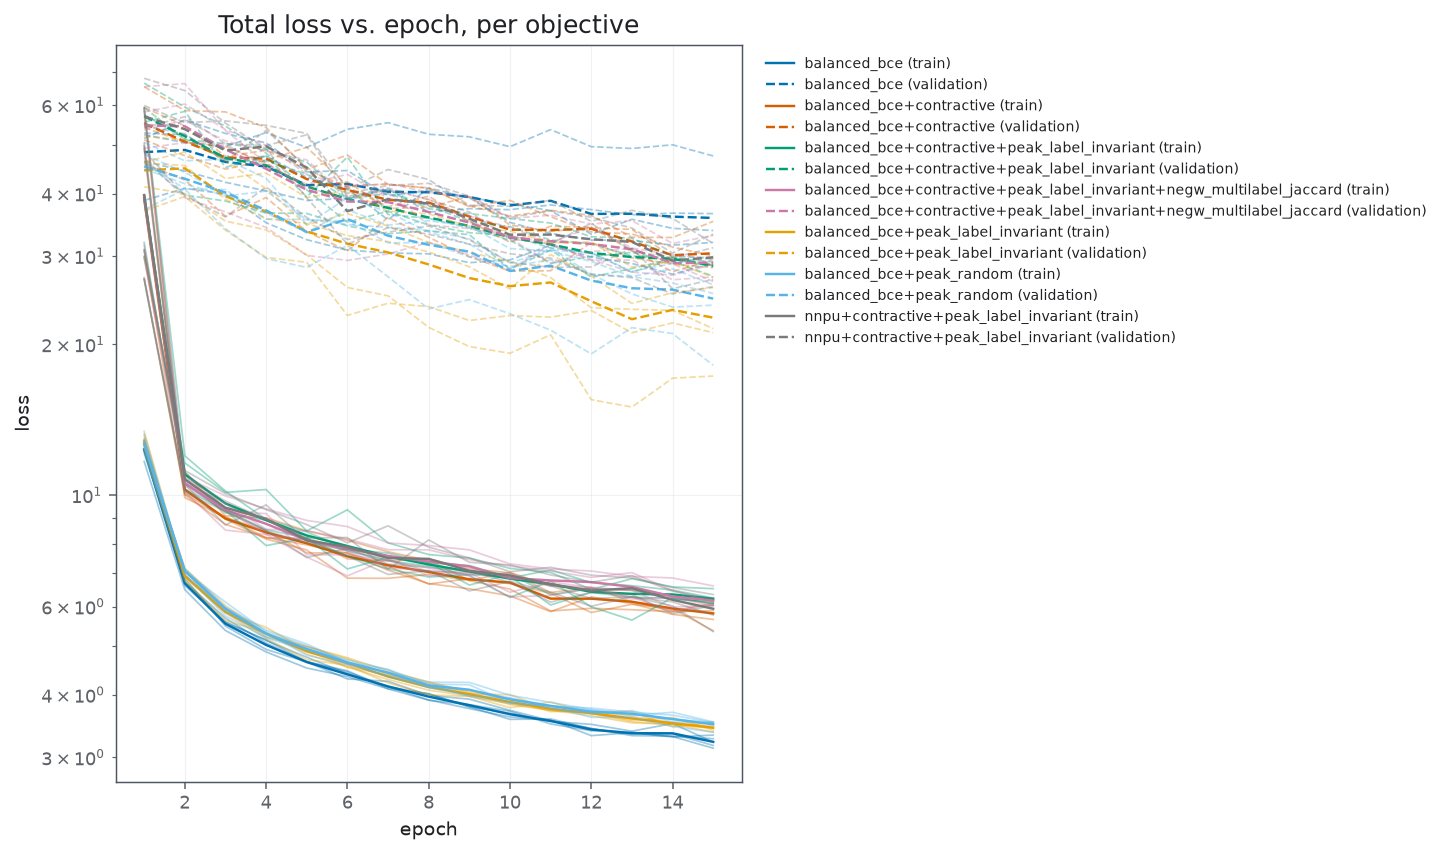

In [13]:
_ = plot_loss_component(epoch_frame, "total_loss", "validation_total_loss", "Total loss vs. epoch, per objective")


### Reconstruction loss (Masserstein) — comparable across every objective

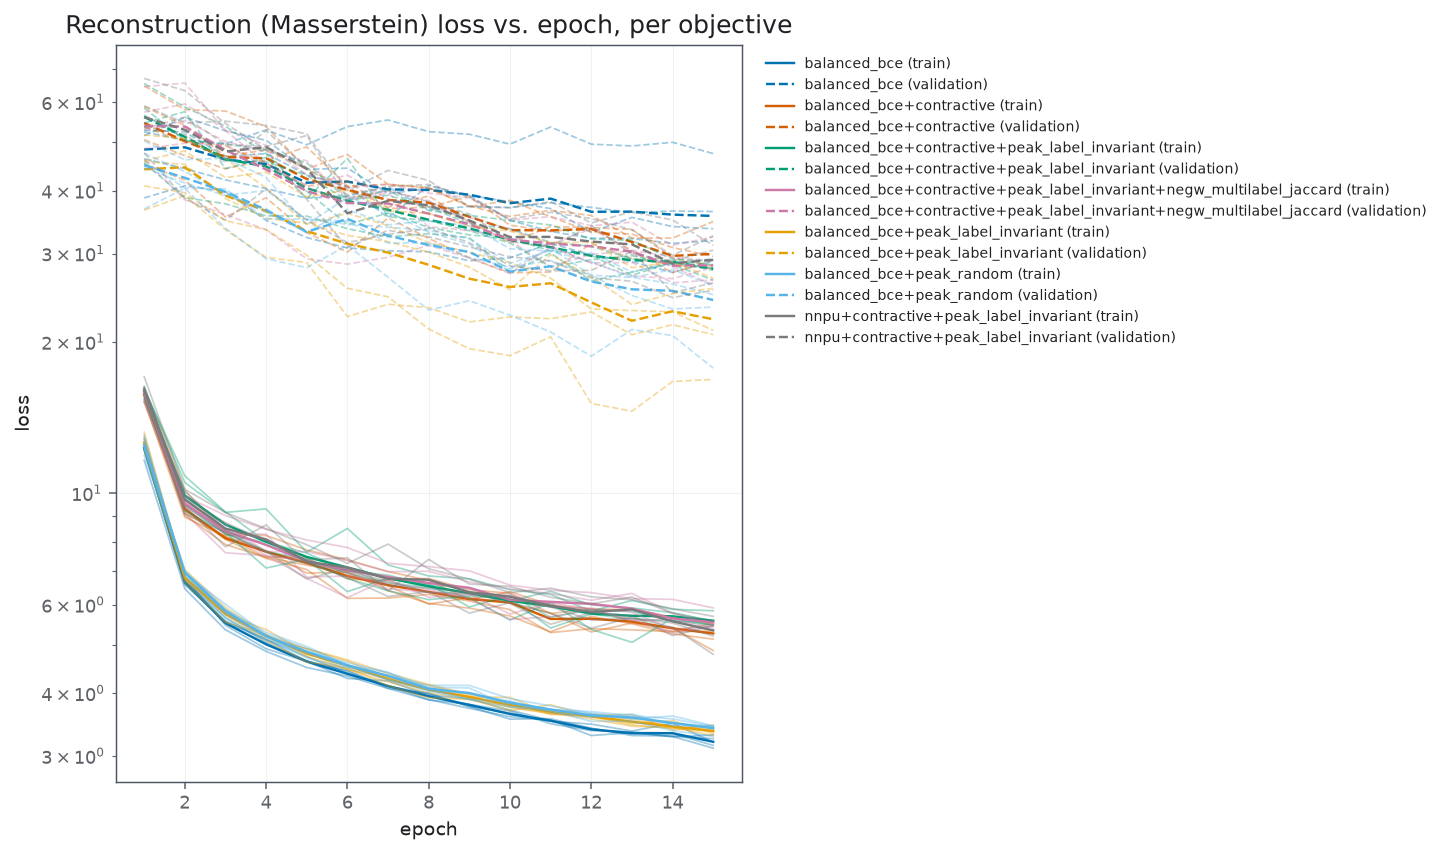

In [14]:
_ = plot_loss_component(epoch_frame, "masserstein", "validation_masserstein", "Reconstruction (Masserstein) loss vs. epoch, per objective")


### Molecule head classification loss

`head_loss` is `balanced_bce` for six objectives and `nnpu` for the seventh
(`grid_0006`) — different loss functions, so the *absolute scale* is not directly
comparable for that one series; only its own convergence trend is.

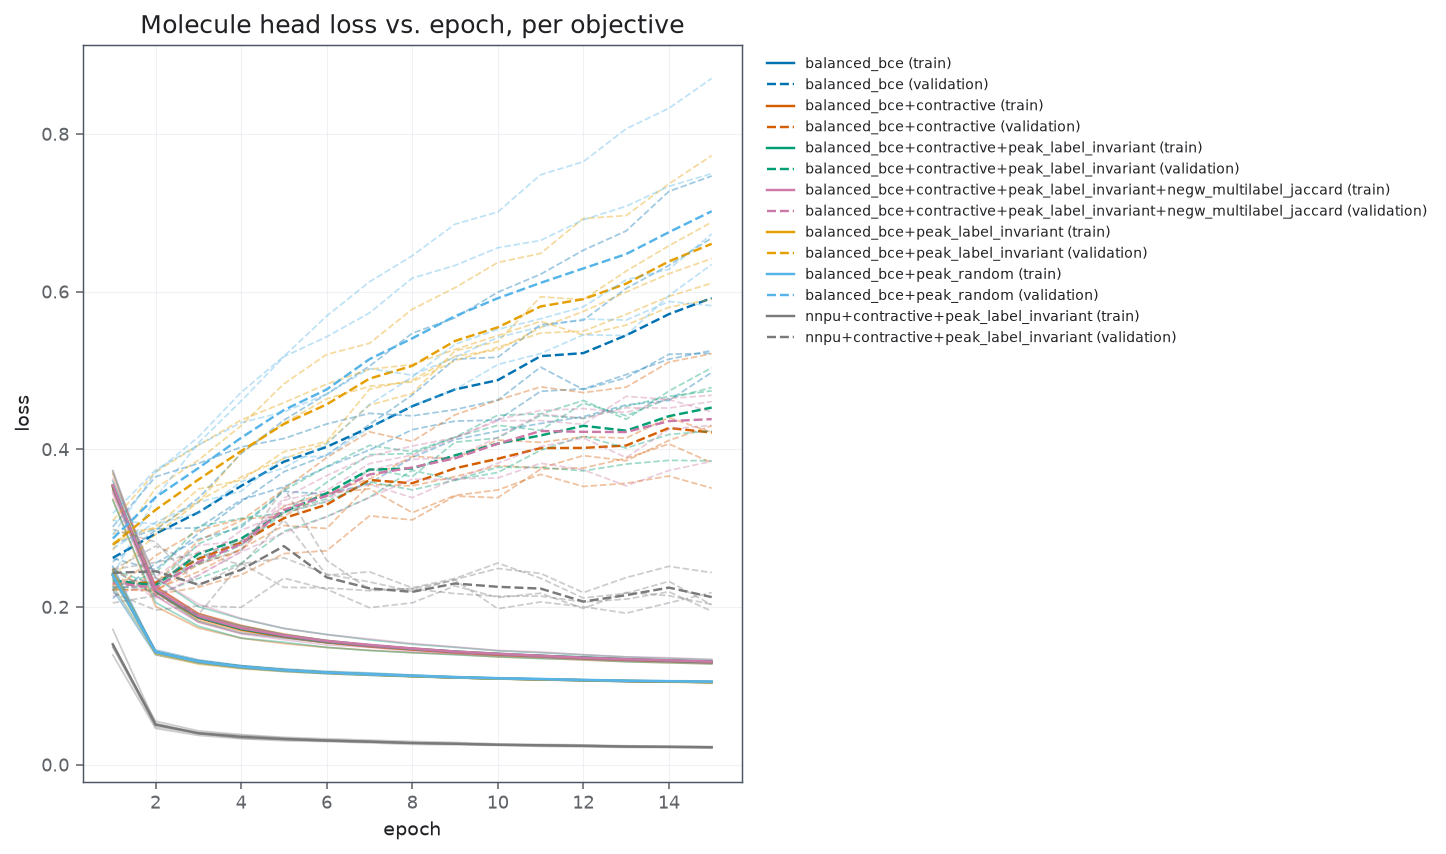

In [15]:
_ = plot_loss_component(epoch_frame, "head_loss", "validation_head_loss", "Molecule head loss vs. epoch, per objective", log_scale=False)


### Contractive regularization loss — only objectives that include it

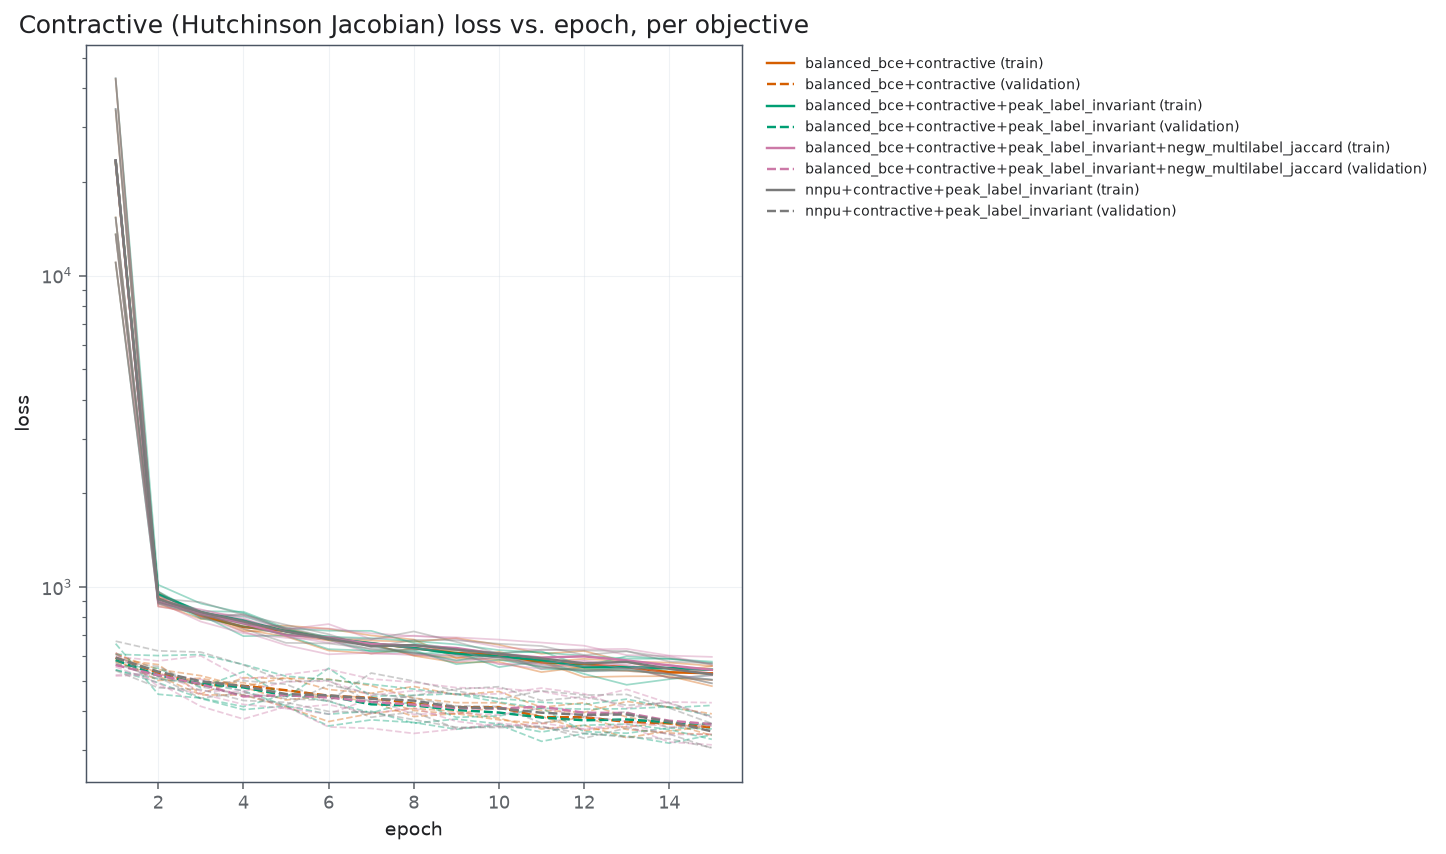

In [16]:
_ = plot_loss_component(epoch_frame, "contractive", "validation_contractive", "Contractive (Hutchinson Jacobian) loss vs. epoch, per objective")


### Contrastive (InfoNCE peak-permutation) loss — only objectives that include it

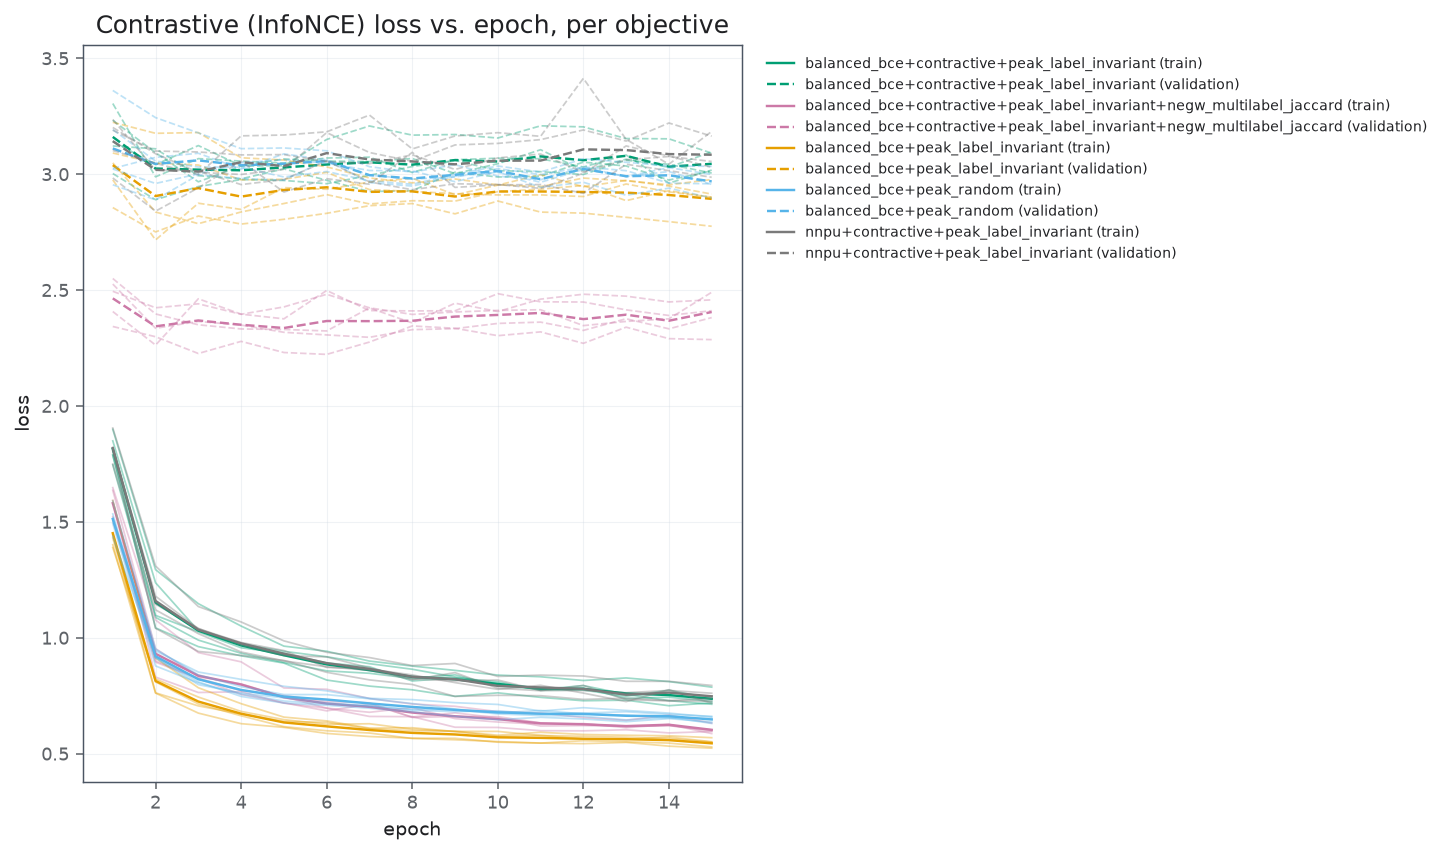

In [17]:
_ = plot_loss_component(epoch_frame, "peak_permutation", "validation_peak_permutation", "Contrastive (InfoNCE) loss vs. epoch, per objective", log_scale=False)


## Notes for the next pass

Facts established here, not yet interpreted:

- **35/35 tasks completed**, every run logged exactly the expected 15 epochs, no
  `NaN`/`Inf` in any logged metric or any saved weight tensor — nothing is silently
  broken at the artifact level.
- **Train/validation gap is large** for every objective (train `total_loss` ~3-6,
  validation ~18-47) — visible directly in the total-loss plot above.
- For a majority of runs, `best_loss` at the final epoch still equals the last epoch's
  validation loss (`still_improving_at_last_epoch` in the final-epoch table) — validation
  had not turned back up yet when training stopped at epoch 15.
- The repository's committed `architecture_predictive_experiment.yaml` no longer
  reproduces the trained run's config fingerprint (`529dc0e4494b...`) — its current
  fingerprint is different. Manually cross-checked every one of the 7 trained
  `objectives` grid values plus the architecture/dataset/training-phase settings
  against this file: all identical. The mismatch is therefore most likely in an
  execution-only field (e.g. `execution.backend: local` here vs. the `slurm`-submitted
  `architecture_predictive_runtime.yaml` actually used on entropy) rather than a drift
  in the trained hyperparameters — but this was not tracked down to the literal byte
  diff, since the exact runtime YAML used remotely was not synced locally.
- `analysis.autoencoder.experiments.campaign_reader.read_campaign` cannot currently
  read this campaign (or, now, the binning campaign either) because of the
  `__cfg_<fingerprint>` directory-naming change — worth fixing in the library before
  building the next topic-module analysis on top of this scaffold, rather than
  re-deriving the workaround above in every new notebook.


## All loss components — combined figure

Same five panels as above (`total_loss`, `masserstein`, `head_loss`, `contractive`,
`peak_permutation`), assembled into one figure for the report.


/tmp/ipykernel_491598/2957605287.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  figure.tight_layout()
/tmp/ipykernel_491598/2957605287.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  figure.tight_layout()
/tmp/ipykernel_491598/2957605287.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  figure.tight_layout()


/tmp/ipykernel_491598/2957605287.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  figure.tight_layout()
/tmp/ipykernel_491598/2957605287.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  figure.tight_layout()


Text(0.5, 0.98, 'Loss over training, per objective — all components')

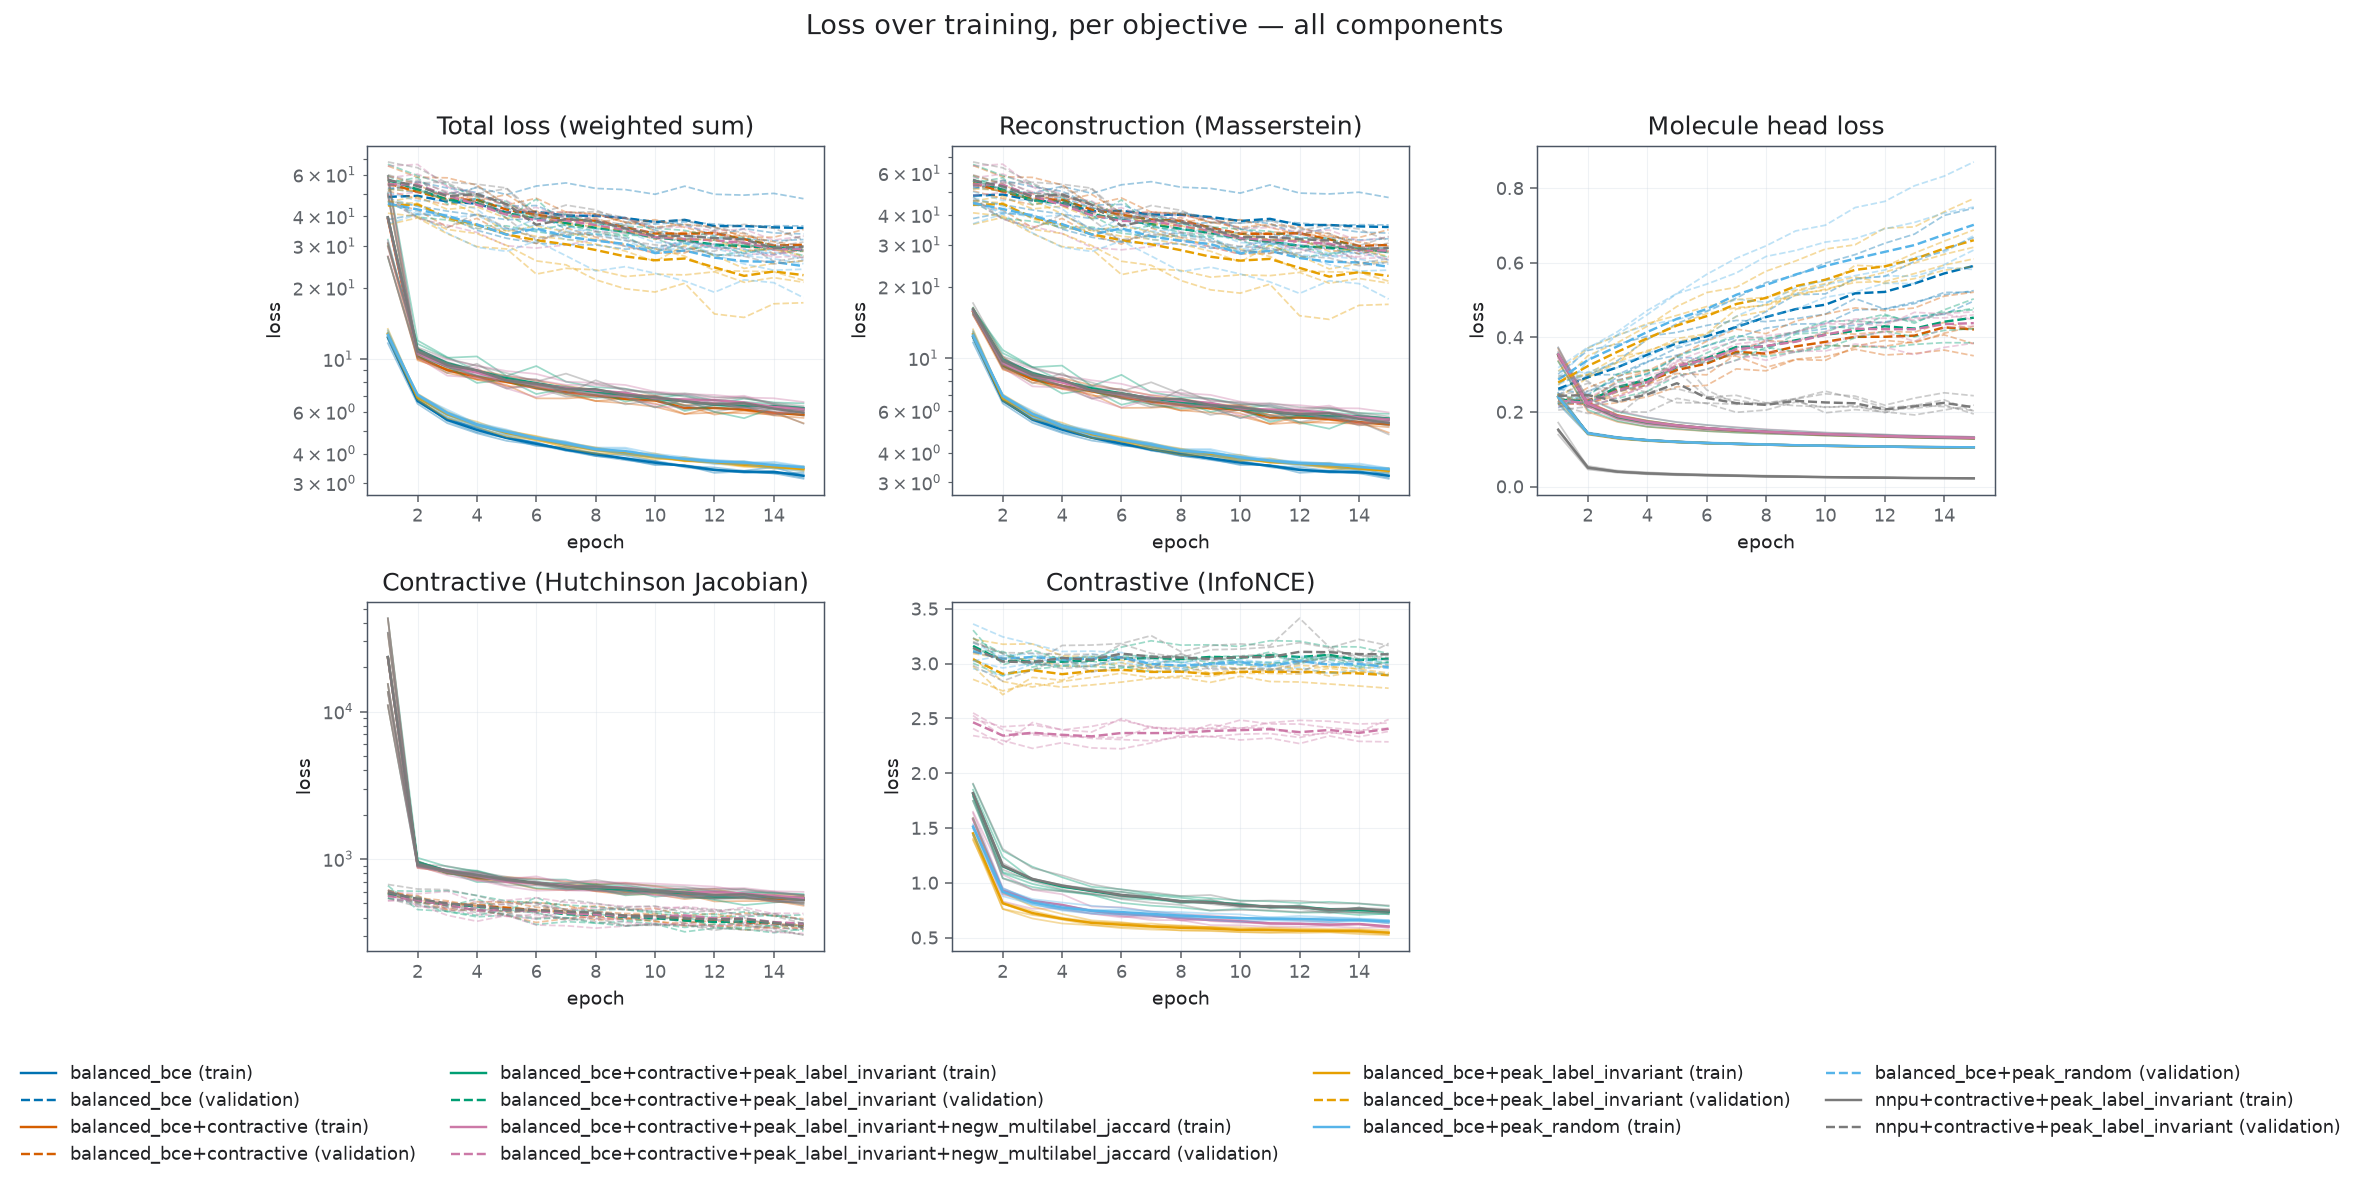

In [18]:
loss_components = [
    ("total_loss", "validation_total_loss", "Total loss (weighted sum)", True),
    ("masserstein", "validation_masserstein", "Reconstruction (Masserstein)", True),
    ("head_loss", "validation_head_loss", "Molecule head loss", False),
    ("contractive", "validation_contractive", "Contractive (Hutchinson Jacobian)", True),
    ("peak_permutation", "validation_peak_permutation", "Contrastive (InfoNCE)", False),
]

combined_figure = plt.figure(figsize=(15.0, 9.5), dpi=theme.figure_dpi)
grid = combined_figure.add_gridspec(3, 3, height_ratios=[1.0, 1.0, 0.32], hspace=0.4, wspace=0.28)
panel_positions = [(0, 0), (0, 1), (0, 2), (1, 0), (1, 1)]
panel_axes = [combined_figure.add_subplot(grid[row, col]) for row, col in panel_positions]

shared_handles, shared_labels = None, None
for axis, (train_key, validation_key, title, log_scale) in zip(panel_axes, loss_components):
    plot_loss_component(epoch_frame, train_key, validation_key, title, log_scale=log_scale, ax=axis)
    handles, labels = axis.get_legend_handles_labels()
    if shared_handles is None or len(handles) > len(shared_handles):
        shared_handles, shared_labels = handles, labels
    axis.get_legend().remove()

legend_axis = combined_figure.add_subplot(grid[2, :])
legend_axis.axis("off")
legend_axis.legend(
    shared_handles, shared_labels, loc="center", ncol=4, frameon=theme.legend_frame, fontsize=9,
)

combined_figure.suptitle("Loss over training, per objective — all components", fontsize=14)
